<a href="https://colab.research.google.com/github/jabrell/numerical_methods/blob/main/sugar_tax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sugar tax model

The government wants to add a tax on sugar consumption. We should create a simple
numeric model to examine the impact of the tax on the equilibrium quantity and price
in the sugar market.

We have given the following simplifying assumptions:
- The sugar market is perfectly competitive
- Aggregated demand and supply can be represented by linear functions

In addition, we are given the following data:

| Parameter | Value |
| --- | --- |
| Observed equilibrium quantity | 350'000 t |
| Observed equilibrium price | 2'000 CHF/t |
| Price elasticity of demand | -1 |
| Price elasticity of supply | 1.6 |

## Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

## Model formulation

Given the linearity assumption, we write the following functions for Demand (D)
and Supply (S) as a function of the market price (P). We assume that consumers pay
the tax (t) and, thus, pay the price P + t

$$D = a - b*(P + t)$$
$$S = c + d*P$$

The market is cleared, when supply equals demand:
$$S = D$$

Substituting demand and supply into the market clearing equation, we can solve for the
equilibrium price. The quantity then follows by substituting the price into the supply
and demand curve:

$$P^* = \frac{a - c - b*t}{b + d}$$
$$Q^* = c + d*P^*$$

To implement this, we define several functions that allow us to plot the model
and to get the equilibrium given a set of parameters.

In [3]:
def demand(price: float, tax: float, a: float, b: float) -> float:
    """
    Calculate the demand based on the price and tax using a linear demand function.

    D = a - b * (price + tax)

    Args:
        price (float): The price of the good.
        tax (float): The tax applied to the good.
        a (float): The intercept of the linear demand function.
        b (float): The slope of the linear demand function.
    Returns:
        The demand for the good.
    """
    demand = max(0, a - b * (price + tax))
    return demand

def supply(price: float, c: float, d: float) -> float:
    """
    Calculate the supply based on the price and tax using a linear supply function.

    S = c + d * (price - tax) 

    Args:
        price (float): The price of the good.
        c (float): The intercept of the linear supply function.
        d (float): The slope of the linear supply function.
    Returns:
        The supply of the good.
    """
    supply = max(0, c + d * price)
    return supply

def calculate_equilibrium(
        tax: float, 
        a: float, 
        b: float, 
        c: float, 
        d: float
    ) -> tuple[float, float]:
    """ Provide the equilibrium quantity given parameters
    
    Args:
        tax (float): Quantity tax on the consumer side
        a (float): Demand intercept
        b (float): Demand slope
        c (float): Supply intercept
        d (float): Supply slope

    Returns:
        A tuple containing the equilibrium price and quantity.
    """
    # Calculate the equilibrium price
    equilibrium_price = (a - c  - b*tax) / (b + d)
    
    # Calculate the equilibrium quantity using either demand or supply function
    equilibrium_quantity = demand(equilibrium_price, tax, a, b)
    
    return {"price": equilibrium_price, "quantity": equilibrium_quantity}

def calculate_rents(
        tax: float, 
        a: float, 
        b: float, 
        c: float, 
        d: float
    ) -> dict[str, float]:
    """ Calculate consumer and producer rents given parameters
    
    Args:
        tax (float): Quantity tax on the consumer side
        a (float): Demand intercept
        b (float): Demand slope
        c (float): Supply intercept
        d (float): Supply slope

    Returns:
        A dictionary containing consumer and producer rents.
    """
    equilibrium = calculate_equilibrium(tax, a, b, c, d)
    equilibrium_price = equilibrium["price"]
    equilibrium_quantity = equilibrium["quantity"]
    
    res = {
        "consumer_rent": 0.5 * equilibrium_quantity * (a - (equilibrium_price + tax)),
        "producer_rent": 0.5 * equilibrium_quantity * (equilibrium_price - c),
        "tax_revenues": tax * equilibrium_quantity
    }
    return res 


## Data

We need to determine the intercept and slope of the demand and supply function,
respectively. The price and quantity of the initial equilibrium is observed and 
the price elasticity of supply and demand is provided. We construct the parameters,
such that initial equilibrium is achieved in the model (in the absence of a tax). 

In [4]:
def calibrate_model(
        price_0: float, 
        quantity_0: float,
        demand_elas: float,
        supply_elas: float
    ) -> dict[str, float]:
    """ Calibrate the demand and supply parameters based on observed price,
    quantity, and elasticities.

    Args:
        price_0 (float): The observed price.
        quantity_0 (float): The observed quantity.
        demand_elas (float): The price elasticity of demand.
        supply_elas (float): The price elasticity of supply.
    
    Returns:
        A dictionary containing the calibrated parameters a, b, c, and d.
    """
    # demand parameters
    b = - demand_elas * quantity_0 / price_0
    a = quantity_0 + b * price_0

    # supply parameters
    d = supply_elas * quantity_0 / price_0
    c = quantity_0 - d * price_0
    
    return {"a": a, "b": b, "c": c, "d": d}

model_parameters = calibrate_model(2_000, 350_000, -1, 1.6)
model_parameters

{'a': 700000.0, 'b': 175.0, 'c': -210000.0, 'd': 280.0}

## Graphical solution

In [5]:
def plot_model(model_parameters: dict[str, float], tax: float) -> None:
    """ Plot the demand and supply curves based on the calibrated parameters and tax.

    Args:
        model_parameters (dict[str, float]): A dictionary containing the 
            parameters a, b, c, and d.
        tax (float): The quantity tax on the consumer side.
    """
    a = model_parameters["a"]
    b = model_parameters["b"]
    c = model_parameters["c"]
    d = model_parameters["d"]

    # Generate price range for plotting
    price_range = np.linspace(0, 4000, 50)
    
    # Calculate demand and supply for the price range
    demand_values = [demand(price, tax, a, b) for price in price_range]
    supply_values = [supply(price, c, d) for price in price_range] 
        

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(demand_values, price_range, label='Demand', color='blue')
    plt.plot(supply_values, price_range,label='Supply', color='orange')
    if tax > 0:
        demand_values_no_tax = [demand(price, 0, a, b) for price in price_range]
        plt.plot(demand_values_no_tax, 
                 price_range, 
                 label='Demand (no tax)', 
                 color='blue', 
                 linestyle='dashed')
    
    # Calculate equilibrium for annotation
    equilibrium = calculate_equilibrium(tax, a, b, c, d)
    equilibrium_price = equilibrium["price"]
    equilibrium_quantity = equilibrium["quantity"]
    
    # Annotate equilibrium point
    plt.scatter(equilibrium_quantity, equilibrium_price, color='red', zorder=5)
    plt.title('Demand and Supply Curves with Tax')
    plt.xlabel('Quantity')
    plt.xlim(0, 800_000)
    plt.ylabel('Price')
    plt.ylim(0, 4_500)
    plt.grid()
    plt.legend()
    plt.show()

Plot the equilibrium with for a given tax values and compare against the original 
equilibrium.

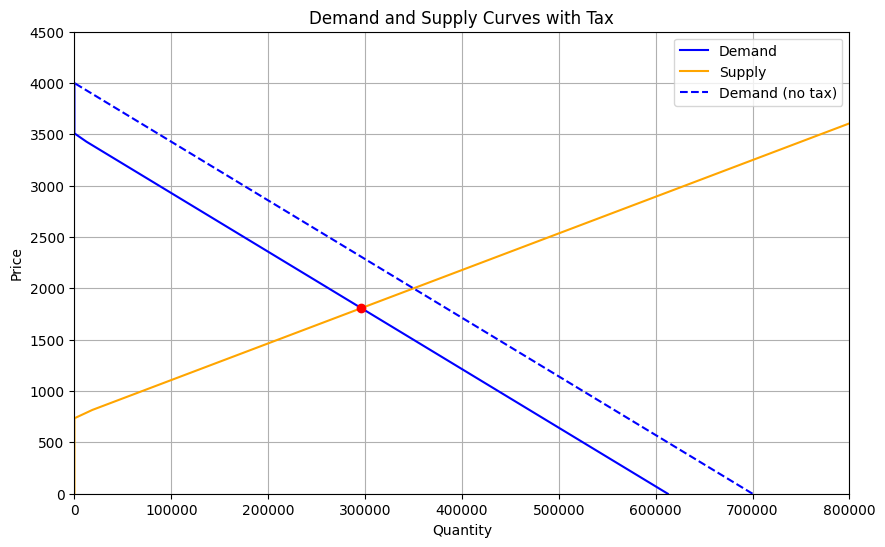

In [6]:
plot_model(model_parameters, tax=500)

## Simulations

We let the tax run over a given range and explore the tax revenues equilibrium price
and quantity:

In [7]:
def simulate_tax_effects(
        taxes: list[float], 
        model_parameters: dict[str, float]
    ) -> list[dict[str, float]]:
    """ Simulate the effects of a tax on equilibrium price and quantity.
    
    Args:
        taxes (list[float]): A list of quantity taxes on the consumer side.
        model_parameters (dict[str, float]): A dictionary containing the 
            parameters a, b, c, and d.
    
    Returns:
        A list of dictionaries containing the tax, equilibrium price, and 
        equilibrium quantity for each tax level.    
    """
    lst_results = []
    
    base_results = model_parameters.copy()

    for tax in taxes:
        equilibrium = calculate_equilibrium(
            tax, 
            base_results["a"], 
            base_results["b"], 
            base_results["c"], 
            base_results["d"]
        )
        equilibrium_price = equilibrium["price"]
        equilibrium_quantity = equilibrium["quantity"]
        # collect results
        # we always want to have a copy of the original parameters to  be sure
        # that the results data are self-contained 
        res = {
            **model_parameters,
            "Tax": tax,
            "Price": equilibrium_price,
            "Quantity": equilibrium_quantity,
            **calculate_rents(
                tax, 
                base_results["a"], 
                base_results["b"], 
                base_results["c"], 
                base_results["d"]
            )
        }
        lst_results.append(res)
    return lst_results

taxes = range(0, 4000, 100)
results = simulate_tax_effects(taxes, model_parameters)
df_res = pd.DataFrame(results)

## 

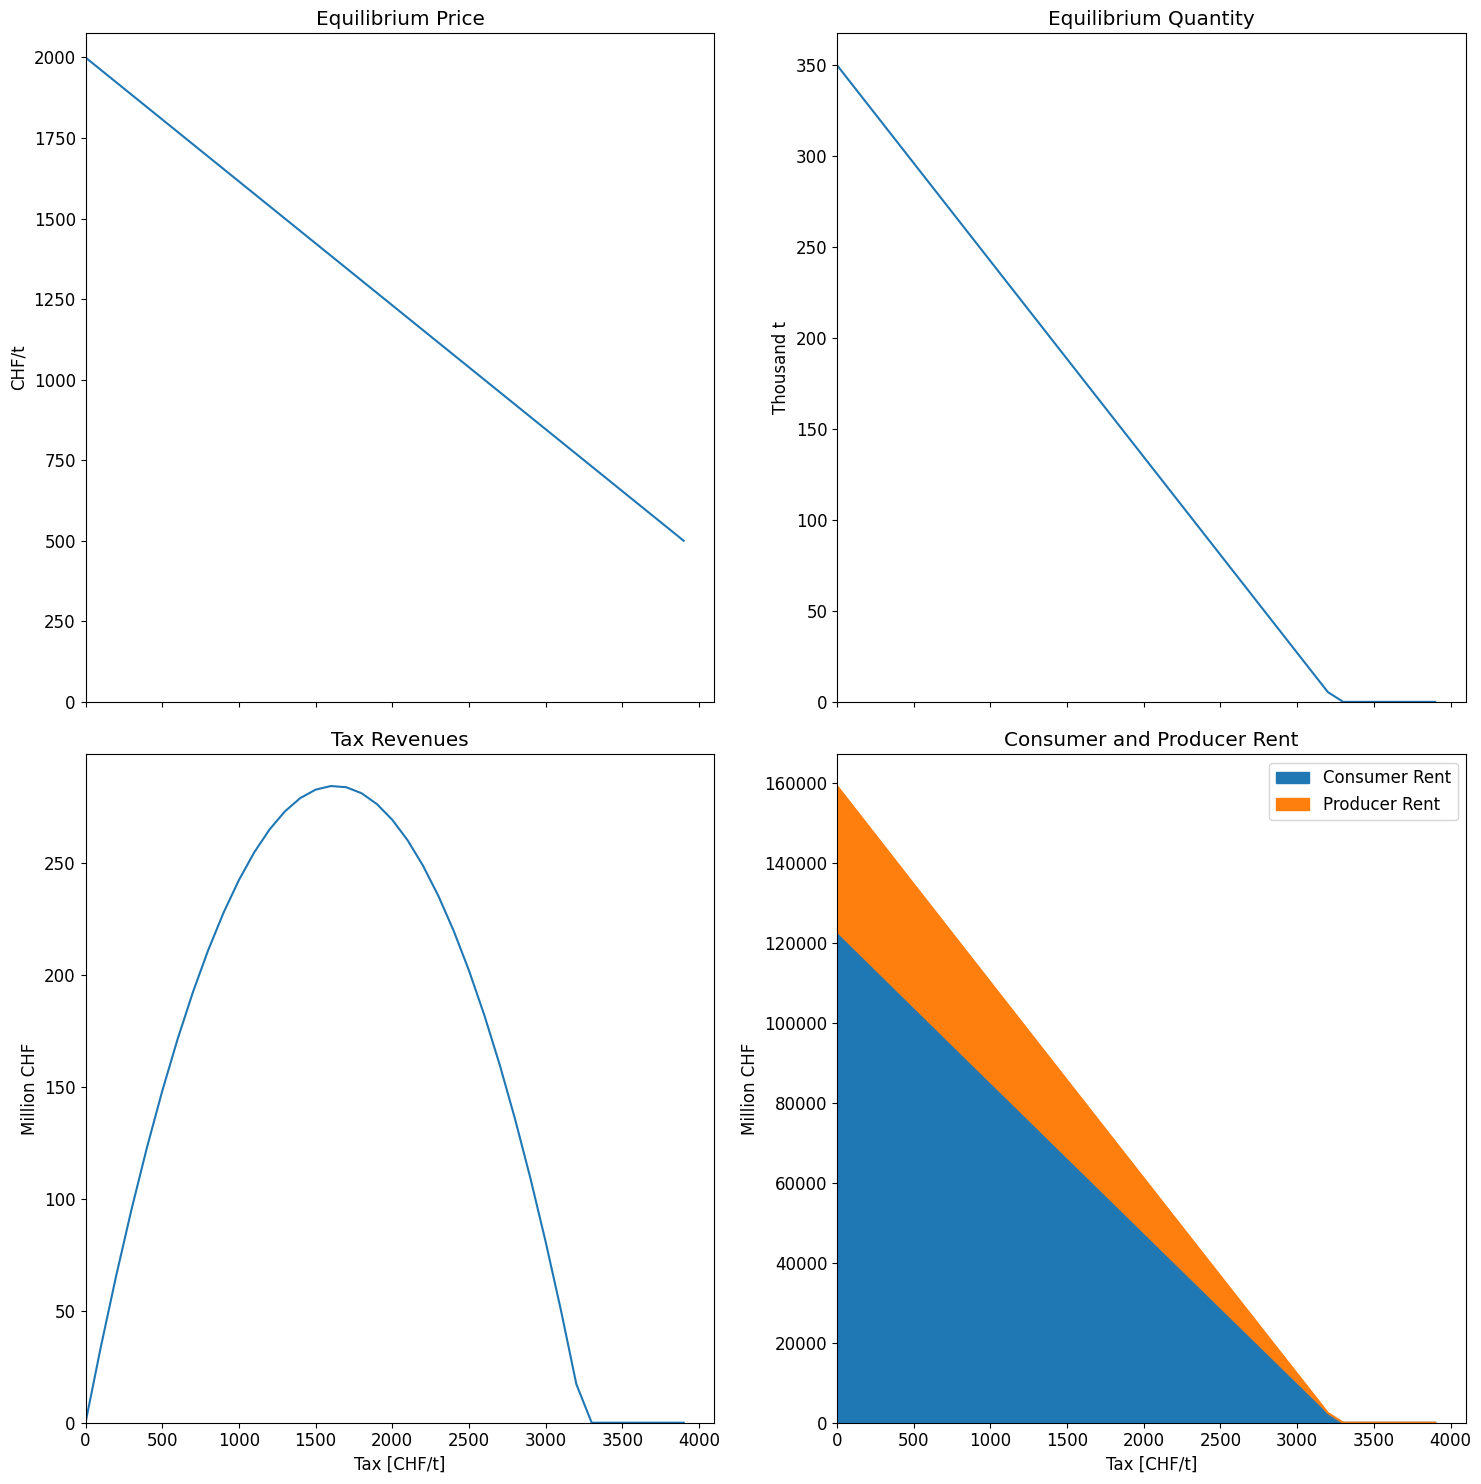

<Figure size 640x480 with 0 Axes>

In [8]:
mpl.rcParams["font.size"] = 12
df_p = df_res.set_index("Tax")[["Price", "Quantity", "tax_revenues"]]
fig, axs = plt.subplots(2, 2, figsize=(15, 15), sharex=True)

# price plot
ax = axs[0, 0]
df_p["Price"].plot(ax=ax, title="Equilibrium Price")
ax.set_xlabel("Tax [CHF/t]")
ax.set_ylabel("CHF/t")
ax.set_ylim(0)

# quantity plot
ax = axs[0, 1]
(df_p["Quantity"]/1_000).plot(ax=ax, title="Equilibrium Quantity")
ax.set_xlabel("Tax [CHF/t]")
ax.set_ylabel("Thousand t")
ax.set_ylim(0)

# revenues plot
ax = axs[1, 0]
(df_p["tax_revenues"]/1_000_000).plot(ax=ax, title="Tax Revenues")
ax.set_xlabel("Tax [CHF/t]")
ax.set_ylabel("Million CHF")
ax.set_xlim(0, 4100)
ax.set_ylim(0)

# Welfare plot
ax = axs[1, 1]
df_ = (
    df_res
    .set_index("Tax")
    [["consumer_rent", "producer_rent"]]
    .rename(columns={"consumer_rent": "Consumer Rent", "producer_rent": "Producer Rent"})
    .div(1_000_000)
)
df_.plot.area(ax=ax, title="Consumer and Producer Rent", stacked=True)
ax.set_xlabel("Tax [CHF/t]")
ax.set_ylabel("Million CHF")
ax.set_xlim(0, 4100)

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()